# Atividade I - Bank Marketing

**Integrantes:** preencher antes da entrega  
**Turma/grupo:** preencher antes da entrega

Este notebook aplica o ciclo de um projeto supervisionado à base `bank_marketing_completo.csv`. O objetivo é prever a adesão a um depósito a prazo e comparar k-NN, Naive Bayes e regressão logística em dois cenários: o cenário principal, composto apenas por informações disponíveis antes da ligação, e o cenário completo, que mantém todos os atributos para comparação.

O procedimento segue os materiais da disciplina disponíveis no Canvas sobre preparação, transformação, classificação, k-NN, validação cruzada, Naive Bayes e regressão logística. As decisões são comentadas antes de cada bloco relevante.

## 1 Importações e configuração

São usadas somente as bibliotecas permitidas no enunciado: pandas, NumPy, scikit-learn, Matplotlib e Seaborn.

In [1]:
from pathlib import Path
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
RANDOM_STATE = 42
ART_DIR = Path('artifacts')
ART_DIR.mkdir(exist_ok=True)
print('Ambiente configurado.')

Ambiente configurado.


## 2 Leitura e visão geral da base

O arquivo deve estar na mesma pasta do notebook. Isso torna a execução reproduzível no GitHub e evita caminhos específicos de um computador.

In [2]:
candidatos = [
    Path('bank_marketing_completo.csv'),
    Path.cwd() / 'bank_marketing_completo.csv',
]
caminho_csv = next((p for p in candidatos if p.exists()), None)
if caminho_csv is None:
    raise FileNotFoundError('Coloque bank_marketing_completo.csv na mesma pasta do notebook.')

df_original = pd.read_csv(caminho_csv)
print(f'Dimensões: {df_original.shape[0]:,} linhas e {df_original.shape[1]} colunas')
display(df_original.head())
display(pd.DataFrame({'tipo': df_original.dtypes.astype(str), 'ausentes': df_original.isna().sum()}))

Dimensões: 41,188 linhas e 21 colunas


,idade,profissao,estado_civil,escolaridade,inadimplente,financiamento_imobiliario,emprestimo_pessoal,meio_contato,mes,dia_semana,...,contatos_campanha_atual,dias_desde_ultimo_contato,contatos_anteriores,resultado_campanha_anterior,taxa_variacao_emprego,indice_precos_consumidor,indice_confianca_consumidor,euribor_3m,numero_empregados,aderiu
0,56,empregado_domestico,casado,fundamental_4anos,nao,nao,nao,telefone_fixo,mai,seg,...,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
1,57,servicos,casado,ensino_medio,desconhecido,nao,nao,telefone_fixo,mai,seg,...,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
2,37,servicos,casado,ensino_medio,nao,sim,nao,telefone_fixo,mai,seg,...,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
3,40,administrativo,casado,fundamental_6anos,nao,nao,nao,telefone_fixo,mai,seg,...,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
4,56,servicos,casado,ensino_medio,nao,nao,sim,telefone_fixo,mai,seg,...,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao


,tipo,ausentes
idade,int64,0
profissao,str,0
estado_civil,str,0
escolaridade,str,0
inadimplente,str,0
financiamento_imobiliario,str,0
emprestimo_pessoal,str,0
meio_contato,str,0
mes,str,0
dia_semana,str,0


## 3 Qualidade dos dados

São verificados valores ausentes, duplicatas, categorias marcadas como `desconhecido` e o código especial 999. As duplicatas exatas são removidas antes da divisão para impedir que o mesmo registro apareça simultaneamente no treino e no teste. `desconhecido` é preservado como categoria informativa. O valor 999 em `dias_desde_ultimo_contato` significa que o cliente nunca foi contatado e não deve ser tratado como uma quantidade literal de dias.

In [3]:
resumo_qualidade = pd.Series({
    'linhas': len(df_original),
    'colunas': df_original.shape[1],
    'valores_ausentes': int(df_original.isna().sum().sum()),
    'duplicatas_exatas': int(df_original.duplicated().sum()),
    'registros_com_999': int((df_original['dias_desde_ultimo_contato'] == 999).sum()),
})
display(resumo_qualidade.to_frame('valor'))

colunas_texto = df_original.select_dtypes(include=['object', 'string']).columns
desconhecidos = (df_original[colunas_texto] == 'desconhecido').sum()
display(desconhecidos[desconhecidos > 0].to_frame('quantidade_desconhecido'))

df = df_original.drop_duplicates().reset_index(drop=True)
print(f'Após remover duplicatas: {len(df):,} linhas.')

,valor
linhas,41188
colunas,21
valores_ausentes,0
duplicatas_exatas,12
registros_com_999,39673


,quantidade_desconhecido
profissao,330
estado_civil,80
escolaridade,1731
inadimplente,8597
financiamento_imobiliario,990
emprestimo_pessoal,990


Após remover duplicatas: 41,176 linhas.


## 4 Análise exploratória

A classe positiva é minoritária. Por isso, a acurácia isolada pode favorecer modelos que quase sempre preveem `nao`. As visualizações seguintes examinam a distribuição do alvo e associações com o histórico da campanha, o meio de contato, o mês e a duração da ligação.

,quantidade,percentual
aderiu,,
nao,36537,88.733728
sim,4639,11.266272


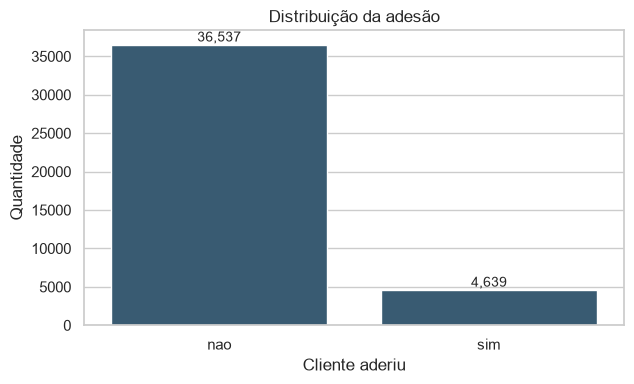

In [4]:
dist_alvo = df['aderiu'].value_counts().rename_axis('aderiu').to_frame('quantidade')
dist_alvo['percentual'] = 100 * dist_alvo['quantidade'] / len(df)
display(dist_alvo)

fig, ax = plt.subplots(figsize=(6.5, 4))
sns.countplot(data=df, x='aderiu', order=['nao', 'sim'], ax=ax, color='#2F5D7C')
ax.set(title='Distribuição da adesão', xlabel='Cliente aderiu', ylabel='Quantidade')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig(ART_DIR / '01_distribuicao_alvo.png', dpi=180, bbox_inches='tight')
plt.show()

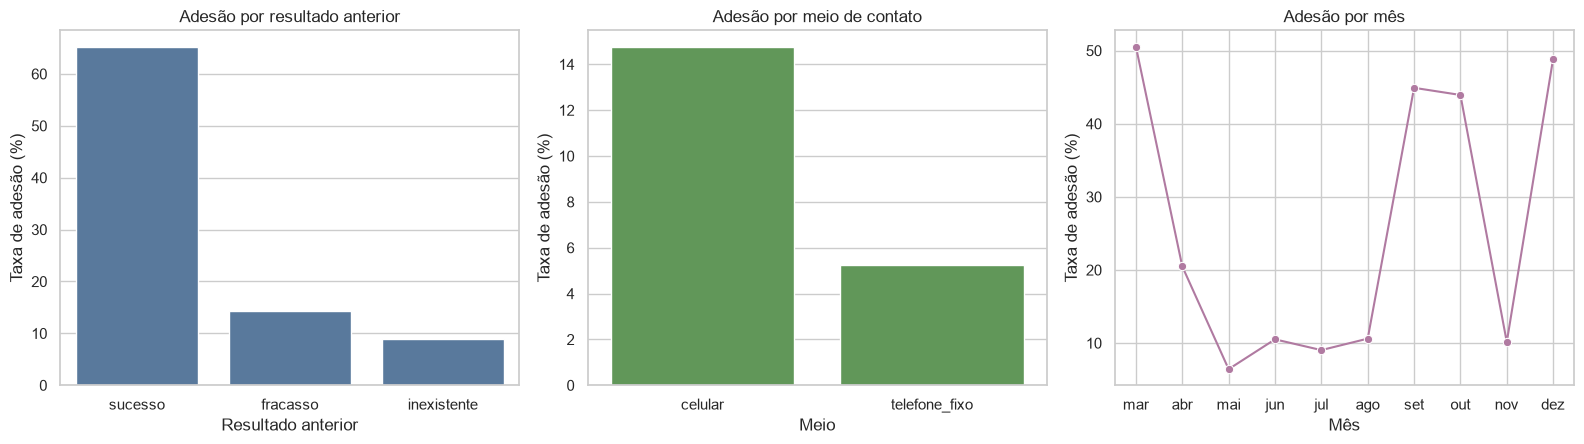

,resultado_anterior,meio_contato
sucesso,0.651129,NaN
fracasso,0.142286,NaN
inexistente,0.088324,NaN
celular,NaN,0.147389
telefone_fixo,NaN,0.052324


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

taxa_anterior = (df.groupby('resultado_campanha_anterior')['aderiu']
                   .apply(lambda s: (s == 'sim').mean()).sort_values(ascending=False))
sns.barplot(x=taxa_anterior.index, y=100*taxa_anterior.values, ax=axes[0], color='#4E79A7')
axes[0].set(title='Adesão por resultado anterior', xlabel='Resultado anterior', ylabel='Taxa de adesão (%)')

taxa_meio = (df.groupby('meio_contato')['aderiu']
              .apply(lambda s: (s == 'sim').mean()).sort_values(ascending=False))
sns.barplot(x=taxa_meio.index, y=100*taxa_meio.values, ax=axes[1], color='#59A14F')
axes[1].set(title='Adesão por meio de contato', xlabel='Meio', ylabel='Taxa de adesão (%)')

ordem_mes = ['mar','abr','mai','jun','jul','ago','set','out','nov','dez']
taxa_mes = (df.groupby('mes')['aderiu'].apply(lambda s: (s == 'sim').mean())
             .reindex(ordem_mes).dropna())
sns.lineplot(x=taxa_mes.index, y=100*taxa_mes.values, marker='o', ax=axes[2], color='#B07AA1')
axes[2].set(title='Adesão por mês', xlabel='Mês', ylabel='Taxa de adesão (%)')

plt.tight_layout()
plt.savefig(ART_DIR / '02_relacoes_categoricas.png', dpi=180, bbox_inches='tight')
plt.show()
display(pd.concat({'resultado_anterior': taxa_anterior, 'meio_contato': taxa_meio}, axis=1))

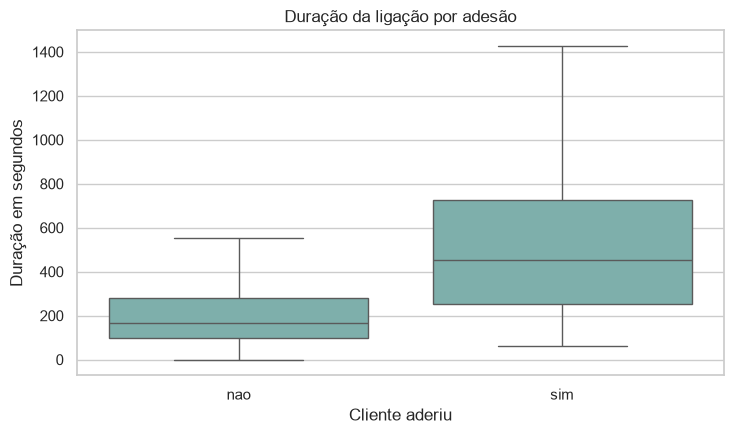

,count,median,mean
aderiu,,,
nao,36537,164.0,220.9
sim,4639,449.0,553.3


In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
amostra_plot = df.sample(min(12000, len(df)), random_state=RANDOM_STATE)
sns.boxplot(data=amostra_plot, x='aderiu', y='duracao_ligacao_seg', order=['nao','sim'],
            showfliers=False, ax=ax, color='#76B7B2')
ax.set(title='Duração da ligação por adesão', xlabel='Cliente aderiu', ylabel='Duração em segundos')
plt.tight_layout()
plt.savefig(ART_DIR / '03_duracao_por_adesao.png', dpi=180, bbox_inches='tight')
plt.show()

display(df.groupby('aderiu')['duracao_ligacao_seg'].agg(['count','median','mean']).round(1))

A duração separa fortemente as classes, mas só é conhecida depois que a ligação termina. Usá-la para decidir quem deve ser contatado produziria vazamento de informação. Assim, ela é excluída do cenário principal e mantida apenas no cenário completo, como comparação diagnóstica.

## 5 Preparação e divisão dos dados

O código 999 é convertido em ausência e acompanhado por um indicador binário. As transformações aprendidas com os dados, como mediana, média, desvio-padrão e categorias do one-hot, ficam dentro de um pipeline e são ajustadas somente no treino. A divisão reserva 30% para teste, preserva a proporção das classes e usa `random_state=42`.

In [7]:
X_base = df.drop(columns='aderiu').copy()
y = (df['aderiu'] == 'sim').astype(int)

X_base['contato_anterior_registrado'] = (X_base['dias_desde_ultimo_contato'] != 999).astype(int)
X_base['dias_desde_ultimo_contato'] = X_base['dias_desde_ultimo_contato'].replace(999, np.nan)

X_treino_base, X_teste_base, y_treino, y_teste = train_test_split(
    X_base, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

cenarios = {
    'principal': [c for c in X_base.columns if c != 'duracao_ligacao_seg'],
    'completo': list(X_base.columns),
}

print('Treino:', X_treino_base.shape, '| Teste:', X_teste_base.shape)
print('Proporção positiva no treino:', round(y_treino.mean(), 4))
print('Proporção positiva no teste:', round(y_teste.mean(), 4))
print('Atributo excluído no cenário principal: duracao_ligacao_seg')

Treino: (28823, 21) | Teste: (12353, 21)
Proporção positiva no treino: 0.1127
Proporção positiva no teste: 0.1127
Atributo excluído no cenário principal: duracao_ligacao_seg


In [8]:
def criar_preprocessador(X):
    numericas = X.select_dtypes(include=np.number).columns.tolist()
    categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

    receita_numerica = Pipeline([
        ('imputacao', SimpleImputer(strategy='median')),
        ('escala', StandardScaler()),
    ])
    receita_categorica = Pipeline([
        ('imputacao', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer([
        ('num', receita_numerica, numericas),
        ('cat', receita_categorica, categoricas),
    ], sparse_threshold=0)

preprocessadores = {
    nome: criar_preprocessador(X_treino_base[colunas])
    for nome, colunas in cenarios.items()
}
print('Preprocessadores definidos sem acessar o conjunto de teste.')

Preprocessadores definidos sem acessar o conjunto de teste.


## 6 Escolha de hiperparâmetros

Como indicado no material de validação cruzada, a busca ocorre somente no conjunto de treino. Para reduzir o custo do k-NN, a grade é avaliada em uma amostra estratificada do treino; o modelo final será ajustado com todas as linhas de treino. O mesmo princípio é aplicado ao parâmetro `C` da regressão logística. A métrica de seleção é o F1 da classe `sim`.

In [9]:
def amostra_estratificada(X, y, n):
    if len(X) <= n:
        return X.copy(), y.copy()
    X_a, _, y_a, _ = train_test_split(
        X, y, train_size=n, random_state=RANDOM_STATE, stratify=y
    )
    return X_a, y_a

cv_busca = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_knn, y_knn = amostra_estratificada(
    X_treino_base[cenarios['principal']], y_treino, 6000
)
pipe_knn_busca = Pipeline([
    ('preparo', clone(preprocessadores['principal'])),
    ('modelo', KNeighborsClassifier(n_jobs=-1)),
])
busca_knn = GridSearchCV(
    pipe_knn_busca,
    {'modelo__n_neighbors': [5, 15, 31, 51], 'modelo__weights': ['uniform', 'distance']},
    scoring='f1', cv=cv_busca, n_jobs=1, return_train_score=False
)
inicio = time.time()
busca_knn.fit(X_knn, y_knn)
print('Melhor configuração k-NN:', busca_knn.best_params_)
print('F1 médio na busca:', round(busca_knn.best_score_, 4), '| segundos:', round(time.time()-inicio, 1))
display(pd.DataFrame(busca_knn.cv_results_)[
    ['param_modelo__n_neighbors','param_modelo__weights','mean_test_score','std_test_score']
].sort_values('mean_test_score', ascending=False).head(8))

Melhor configuração k-NN: {'modelo__n_neighbors': 15, 'modelo__weights': 'distance'}
F1 médio na busca: 0.3667 | segundos: 3.8


,param_modelo__n_neighbors,param_modelo__weights,mean_test_score,std_test_score
3,15,distance,0.366723,0.051311
2,15,uniform,0.366377,0.057021
1,5,distance,0.356202,0.032234
0,5,uniform,0.355119,0.034165
5,31,distance,0.352350,0.052968
4,31,uniform,0.351688,0.054179
7,51,distance,0.334385,0.045025
6,51,uniform,0.333168,0.046241


In [10]:
X_log, y_log = amostra_estratificada(
    X_treino_base[cenarios['principal']], y_treino, 12000
)
pipe_log_busca = Pipeline([
    ('preparo', clone(preprocessadores['principal'])),
    ('modelo', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
busca_log = GridSearchCV(
    pipe_log_busca, {'modelo__C': [0.01, 0.1, 1.0, 10.0]},
    scoring='f1', cv=cv_busca, n_jobs=1
)
busca_log.fit(X_log, y_log)
print('Melhor C:', busca_log.best_params_)
print('F1 médio na busca:', round(busca_log.best_score_, 4))
display(pd.DataFrame(busca_log.cv_results_)[
    ['param_modelo__C','mean_test_score','std_test_score']
].sort_values('mean_test_score', ascending=False))

Melhor C: {'modelo__C': 10.0}
F1 médio na busca: 0.3551


,param_modelo__C,mean_test_score,std_test_score
3,10.00,0.355079,0.026093
2,1.00,0.353313,0.023752
1,0.10,0.335459,0.035112
0,0.01,0.303942,0.041466


A base combina atributos contínuos e categorias transformadas em indicadores binários. `GaussianNB` preserva a magnitude dos atributos numéricos, enquanto `BernoulliNB` os reduz a presença/ausência. As duas variantes são comparadas por validação cruzada e a de maior F1 é usada nos dois cenários.

In [11]:
X_nb, y_nb = amostra_estratificada(
    X_treino_base[cenarios['principal']], y_treino, 10000
)
variantes_nb = {'GaussianNB': GaussianNB(), 'BernoulliNB': BernoulliNB()}
comparacao_nb = []
for nome, estimador in variantes_nb.items():
    pipe = Pipeline([
        ('preparo', clone(preprocessadores['principal'])),
        ('modelo', estimador),
    ])
    escores = cross_val_score(pipe, X_nb, y_nb, scoring='f1', cv=cv_busca, n_jobs=1)
    comparacao_nb.append({'variante': nome, 'f1_medio': escores.mean(), 'f1_dp': escores.std(ddof=1)})

comparacao_nb = pd.DataFrame(comparacao_nb).sort_values('f1_medio', ascending=False)
display(comparacao_nb)
melhor_nb_nome = comparacao_nb.iloc[0]['variante']
print('Variante selecionada:', melhor_nb_nome)

,variante,f1_medio,f1_dp
0,GaussianNB,0.413573,0.018716
1,BernoulliNB,0.404603,0.020281


Variante selecionada: GaussianNB


## 7 Treinamento e avaliação nos dois cenários

Os três modelos usam a mesma divisão de treino e teste e a mesma preparação em cada cenário. Os hiperparâmetros são escolhidos no cenário principal, que representa o uso real, e mantidos no cenário completo para que a comparação isole o efeito da inclusão da duração da ligação. São calculadas acurácia, precisão, recall e F1 para as duas classes, além das matrizes de confusão.

In [12]:
melhor_k = int(busca_knn.best_params_['modelo__n_neighbors'])
melhor_peso = busca_knn.best_params_['modelo__weights']
melhor_C = float(busca_log.best_params_['modelo__C'])
modelo_nb = GaussianNB() if melhor_nb_nome == 'GaussianNB' else BernoulliNB()

estimadores = {
    'k-NN': KNeighborsClassifier(n_neighbors=melhor_k, weights=melhor_peso, n_jobs=-1),
    melhor_nb_nome: modelo_nb,
    'Regressão logística': LogisticRegression(C=melhor_C, max_iter=2000, random_state=RANDOM_STATE),
}

resultados = []
matrizes = {}
modelos_ajustados = {}

for cenario, colunas in cenarios.items():
    X_tr = X_treino_base[colunas]
    X_te = X_teste_base[colunas]
    for nome, estimador in estimadores.items():
        print(f'Ajustando {nome} - {cenario}...')
        pipe = Pipeline([
            ('preparo', clone(preprocessadores[cenario])),
            ('modelo', clone(estimador)),
        ])
        pipe.fit(X_tr, y_treino)
        previsto = pipe.predict(X_te)
        rel = classification_report(y_teste, previsto, target_names=['nao','sim'], output_dict=True, zero_division=0)
        resultados.append({
            'cenario': cenario,
            'modelo': nome,
            'acuracia': accuracy_score(y_teste, previsto),
            'precisao_nao': rel['nao']['precision'],
            'recall_nao': rel['nao']['recall'],
            'f1_nao': rel['nao']['f1-score'],
            'precisao_sim': rel['sim']['precision'],
            'recall_sim': rel['sim']['recall'],
            'f1_sim': rel['sim']['f1-score'],
        })
        matrizes[(cenario, nome)] = confusion_matrix(y_teste, previsto)
        modelos_ajustados[(cenario, nome)] = pipe

resultados_df = pd.DataFrame(resultados).sort_values(['cenario','f1_sim'], ascending=[True,False])
display(resultados_df.round(4))
resultados_df.to_csv(ART_DIR / 'resultados_teste.csv', index=False)

Ajustando k-NN - principal...


Ajustando GaussianNB - principal...


Ajustando Regressão logística - principal...


Ajustando k-NN - completo...


Ajustando GaussianNB - completo...


Ajustando Regressão logística - completo...


,cenario,modelo,acuracia,precisao_nao,recall_nao,f1_nao,precisao_sim,recall_sim,f1_sim
5,completo,Regressão logística,0.9091,0.9295,0.9713,0.9499,0.6496,0.4195,0.5098
3,completo,k-NN,0.9042,0.9247,0.9711,0.9473,0.6235,0.3772,0.4700
4,completo,GaussianNB,0.8357,0.9488,0.8612,0.9029,0.3673,0.6343,0.4652
1,principal,GaussianNB,0.8246,0.9418,0.8551,0.8964,0.3386,0.5841,0.4287
0,principal,k-NN,0.8926,0.9121,0.9726,0.9414,0.5489,0.2622,0.3549
2,principal,Regressão logística,0.8991,0.9082,0.9860,0.9455,0.6600,0.2148,0.3241


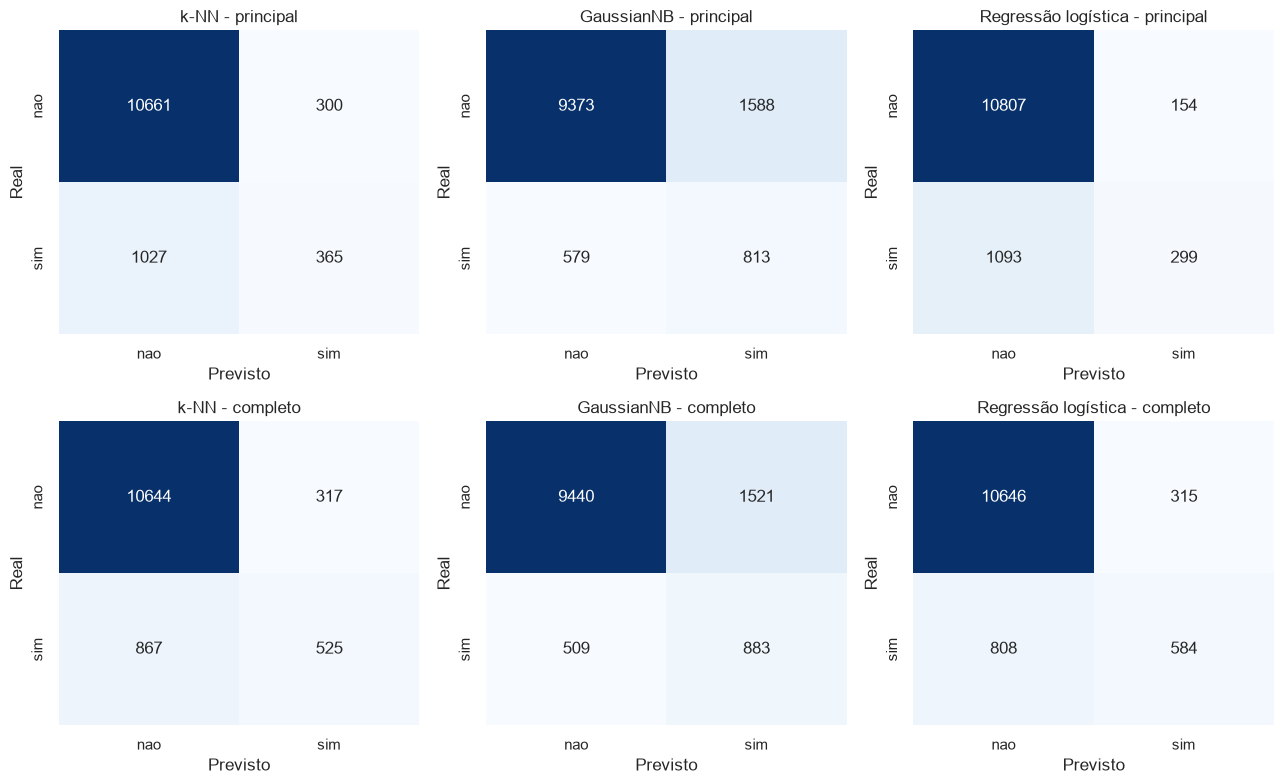

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, ((cenario, nome), matriz) in zip(axes.flat, matrizes.items()):
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['nao','sim'], yticklabels=['nao','sim'])
    ax.set(title=f'{nome} - {cenario}', xlabel='Previsto', ylabel='Real')
plt.tight_layout()
plt.savefig(ART_DIR / '04_matrizes_confusao.png', dpi=180, bbox_inches='tight')
plt.show()

## 8 Validação cruzada do cenário principal

Além do teste final, cada configuração escolhida é avaliada com cinco partições estratificadas dentro do treino completo. A média estima o desempenho típico e o desvio-padrão mostra sua estabilidade entre as dobras.

In [14]:
cv_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_resultados = []
X_cv = X_treino_base[cenarios['principal']]
for nome, estimador in estimadores.items():
    pipe = Pipeline([
        ('preparo', clone(preprocessadores['principal'])),
        ('modelo', clone(estimador)),
    ])
    print('Validação cruzada:', nome)
    escores = cross_val_score(pipe, X_cv, y_treino, scoring='f1', cv=cv_final, n_jobs=1)
    cv_resultados.append({
        'modelo': nome,
        'f1_cv_media': escores.mean(),
        'f1_cv_dp': escores.std(ddof=1),
        'dobras': ', '.join(f'{x:.4f}' for x in escores),
    })

cv_df = pd.DataFrame(cv_resultados).sort_values('f1_cv_media', ascending=False)
display(cv_df)
cv_df.to_csv(ART_DIR / 'validacao_cruzada.csv', index=False)

# Consolidação exigida no enunciado: resultados do teste e validação cruzada
# do cenário principal em uma única tabela.
tabela_consolidada = resultados_df.merge(
    cv_df[['modelo', 'f1_cv_media', 'f1_cv_dp']], on='modelo', how='left'
)
tabela_consolidada.loc[
    tabela_consolidada['cenario'] != 'principal', ['f1_cv_media', 'f1_cv_dp']
] = np.nan
display(tabela_consolidada.round(4))
tabela_consolidada.to_csv(ART_DIR / 'resultados_consolidados.csv', index=False)

Validação cruzada: k-NN


Validação cruzada: GaussianNB


Validação cruzada: Regressão logística


,modelo,f1_cv_media,f1_cv_dp,dobras
1,GaussianNB,0.409963,0.012399,"0.4027, 0.4105, 0.4293, 0.3964, 0.4110"
0,k-NN,0.365588,0.009634,"0.3506, 0.3640, 0.3705, 0.3662, 0.3765"
2,Regressão logística,0.344916,0.020358,"0.3303, 0.3237, 0.3470, 0.3473, 0.3763"


,cenario,modelo,acuracia,precisao_nao,recall_nao,f1_nao,precisao_sim,recall_sim,f1_sim,f1_cv_media,f1_cv_dp
0,completo,Regressão logística,0.9091,0.9295,0.9713,0.9499,0.6496,0.4195,0.5098,NaN,NaN
1,completo,k-NN,0.9042,0.9247,0.9711,0.9473,0.6235,0.3772,0.4700,NaN,NaN
2,completo,GaussianNB,0.8357,0.9488,0.8612,0.9029,0.3673,0.6343,0.4652,NaN,NaN
3,principal,GaussianNB,0.8246,0.9418,0.8551,0.8964,0.3386,0.5841,0.4287,0.4100,0.0124
4,principal,k-NN,0.8926,0.9121,0.9726,0.9414,0.5489,0.2622,0.3549,0.3656,0.0096
5,principal,Regressão logística,0.8991,0.9082,0.9860,0.9455,0.6600,0.2148,0.3241,0.3449,0.0204


## 9 Coeficientes da regressão logística

Os coeficientes são analisados no cenário principal. Como os números foram padronizados, um coeficiente numérico descreve a mudança no logaritmo das chances associada a um desvio-padrão. Nas variáveis one-hot, o sinal indica associação daquela categoria com maior ou menor chance prevista. Essas associações não demonstram causalidade.

,atributo_transformado,coeficiente,odds_ratio
4,num__taxa_variacao_emprego,-2.3036,0.0999
51,cat__mes_mar,1.2640,3.5394
5,num__indice_precos_consumidor,1.1476,3.1506
49,cat__mes_jun,-0.8197,0.4406
44,cat__meio_contato_telefone_fixo,-0.6831,0.5051


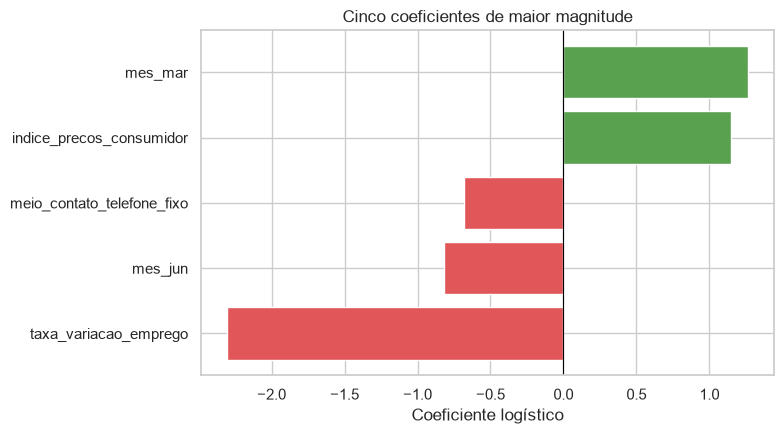

In [15]:
pipe_log_principal = modelos_ajustados[('principal', 'Regressão logística')]
nomes_atributos = pipe_log_principal.named_steps['preparo'].get_feature_names_out()
coeficientes = pipe_log_principal.named_steps['modelo'].coef_[0]
coef_df = pd.DataFrame({'atributo_transformado': nomes_atributos, 'coeficiente': coeficientes})
coef_df['magnitude'] = coef_df['coeficiente'].abs()
top5_coef = coef_df.nlargest(5, 'magnitude').copy()
top5_coef['odds_ratio'] = np.exp(top5_coef['coeficiente'])
display(top5_coef[['atributo_transformado','coeficiente','odds_ratio']].round(4))
top5_coef.to_csv(ART_DIR / 'top5_coeficientes.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
ordem = top5_coef.sort_values('coeficiente')
cores = np.where(ordem['coeficiente'] >= 0, '#59A14F', '#E15759')
ax.barh(ordem['atributo_transformado'].str.replace('num__','').str.replace('cat__',''),
        ordem['coeficiente'], color=cores)
ax.axvline(0, color='black', linewidth=0.8)
ax.set(title='Cinco coeficientes de maior magnitude', xlabel='Coeficiente logístico', ylabel='')
plt.tight_layout()
plt.savefig(ART_DIR / '05_coeficientes_logistica.png', dpi=180, bbox_inches='tight')
plt.show()

## 10 Síntese para decisão

O F1 da classe `sim` é a métrica principal porque a adesão é rara e o banco precisa equilibrar dois erros: falsos negativos deixam de priorizar clientes que poderiam aderir, enquanto falsos positivos consomem tempo de operadores em contatos pouco promissores. O cenário completo tende a parecer superior porque inclui a duração, mas essa informação só existe depois da ligação e não pode sustentar a priorização prévia.

In [16]:
melhor_principal = resultados_df[resultados_df['cenario'] == 'principal'].iloc[0]
melhor_completo = resultados_df[resultados_df['cenario'] == 'completo'].iloc[0]
ganho = melhor_completo['f1_sim'] - melhor_principal['f1_sim']

print(f"Melhor modelo no cenário principal: {melhor_principal['modelo']} "
      f"(F1 sim = {melhor_principal['f1_sim']:.4f}; "
      f"precisão = {melhor_principal['precisao_sim']:.4f}; recall = {melhor_principal['recall_sim']:.4f}).")
print(f"Melhor resultado no cenário completo: {melhor_completo['modelo']} "
      f"(F1 sim = {melhor_completo['f1_sim']:.4f}).")
print(f"Diferença de F1 entre os melhores resultados: {ganho:.4f}.")

resumo_final = {
    'melhor_k': melhor_k,
    'peso_knn': melhor_peso,
    'melhor_C': melhor_C,
    'variante_nb': melhor_nb_nome,
    'melhor_modelo_principal': melhor_principal['modelo'],
    'f1_principal': float(melhor_principal['f1_sim']),
    'melhor_modelo_completo': melhor_completo['modelo'],
    'f1_completo': float(melhor_completo['f1_sim']),
}
(ART_DIR / 'resumo_final.json').write_text(json.dumps(resumo_final, ensure_ascii=False, indent=2), encoding='utf-8')
resumo_final

Melhor modelo no cenário principal: GaussianNB (F1 sim = 0.4287; precisão = 0.3386; recall = 0.5841).
Melhor resultado no cenário completo: Regressão logística (F1 sim = 0.5098).
Diferença de F1 entre os melhores resultados: 0.0811.


{'melhor_k': 15,
 'peso_knn': 'distance',
 'melhor_C': 10.0,
 'variante_nb': 'GaussianNB',
 'melhor_modelo_principal': 'GaussianNB',
 'f1_principal': 0.42868441866596363,
 'melhor_modelo_completo': 'Regressão logística',
 'f1_completo': 0.5098210388476647}

## 11 Declaração de uso de IA generativa

Documentação e correção de erros ortográficos.